# Part 3: Classification of Airline Tweets with Pretrained Transformers

# Understanding the Problem
The goal of this part is to gain hands-on experience with pretrained transformer models by fine-tuning a model on the Twitter US Airline Tweets dataset from Part 1. We will work with transformer-based architectures such as DistilBERT and BERT architectures to accurately classify tweet sentiment into three discrete categories: Negative, Neutral, or Positive.

We are encouraged to experiment with advanced transformer optimization techniques, focusing on:
1. Pretrained Transformer Models
2. Fine-Tuning Strategies
3. Advanced Training Configurations

No exploratory data analysis (EDA) is required in this part. We focus solely on model fine-tuning, learning curve analysis, and confusion matrix evaluation.

In [3]:
# Import libraries
import numpy as np
import pandas as pd
import re
import string

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_scheduler

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import matplotlib.pyplot as plt
import seaborn as sns

# NLTK Downloads
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# Hardware Acceleration Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [4]:
# Load the dataset and the clean tweet text
file_path = 'Tweets.csv'
df = pd.read_csv(file_path)

# Extract the text and the ground truth labels
tweets_df = df[['text', 'airline_sentiment']].copy()

# Map nominal target sentiment labels to integers
label_mapping = {'negative': 0, 'neutral': 1, 'positive': 2}
tweets_df['label'] = tweets_df['airline_sentiment'].map(label_mapping)

# Text preprocessing from Exercise 1
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_tweet_to_text(text: str):
    """
    Cleans raw tweet text by removing URLs, user handles, hashtags, punctuation,
    and digits, followed by lowercasing, tokenization, stopword removal, and lemmatization.
    Args:
        text (str): The raw tweet text string from the dataset.
    Returns:
        str: A unified string of clean, lemmatized tokens (Necessary for Transformer compatibility).
    """

    # Convert to lowercase
    text = text.lower()

    # Remove URLs/Links
    text = re.sub(r'https?://\s*\S+|www\.\S+', '', text)

    # Remove Twitter Handles (@user) and Hashtag symbols (#)
    text = re.sub(r'@\S+', '', text)
    text = re.sub(r'#', '', text)

    # Remove Digits and Numbers
    text = re.sub(r'\d+', '', text)

    # Remove Punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Tokenize text to process word by word
    tokens = word_tokenize(text)

    # Filter Stopwords and apply Lemmatization
    clean_tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words
    ]

    return " ".join(clean_tokens)

# Apply preprocessing to extract text strings
tweets_df['cleaned_text'] = tweets_df['text'].apply(clean_tweet_to_text)

# Filter out rows that ended up with zero valid tokens post-cleaning
tweets_df = tweets_df[tweets_df['cleaned_text'].apply(lambda x: len(x.strip()) > 0)]

# Extract arrays for splitting
X_processed = tweets_df['cleaned_text'].values
y_raw = tweets_df['label'].values

# Stratify=y_raw preserves the 62.6%/21.2%/16.1% class ratio in both train and test sets
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X_processed, y_raw, test_size=0.2, random_state=42, stratify=y_raw)

print(f"Data loaded and cleaned successfully!")
print(f"Final Filtered Dataset Shape: {tweets_df.shape}")
print(f"Train set size               : {len(X_train_raw)} tweets")
print(f"Test set size                : {len(X_test_raw)} tweets")

Data loaded and cleaned successfully!
Final Filtered Dataset Shape: (14620, 4)
Train set size               : 11696 tweets
Test set size                : 2924 tweets


In [5]:
# Define the custom PyTorch Dataset class compatible with Transformer inputs
class AirlineTweetsTransformerDataset(Dataset):
    """
    A custom PyTorch Dataset class designed to process and package raw text
    and labels into compatible inputs for Hugging Face Transformer models like DistilBERT and BERT.
    """
    def __init__(self, texts, labels, tokenizer, max_len):
        """
        Args:
        texts: A collection of raw tweet text strings from the dataset.
        labels: A collection of target labels corresponding to each tweet.
        tokenizer (PreTrainedTokenizer): The Hugging Face tokenizer corresponding to the specific Transformer architecture.
        max_len (int): The maximum sequence length allowed for token padding and truncation.
        """
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        """
        Returns the total number of samples in the dataset.
        """
        return len(self.texts)

    def __getitem__(self, item):
        """
        Returns a single data sample, tokenizes the text, and formats it into PyTorch tensors.
        Args:
            item (int): The index of the item to retrieve from the dataset.
        Returns:
            dict: A dictionary containing 'input_ids' (flattened tensor), 'attention_mask' (flattened tensor),
                  and 'labels' (long tensor).
        """
        text = str(self.texts[item])
        label = self.labels[item]

        # Use the transformer tokenizer to extract input_ids and attention_mask automatically
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Initialize Tokenizers for pretrained models DistilBERT και BERT
tokenizer_distilbert = AutoTokenizer.from_pretrained("distilbert-base-uncased")
tokenizer_bert = AutoTokenizer.from_pretrained("bert-base-uncased")

max_len = 64

# Create Transformer Datasets using the custom class
train_dataset_distil = AirlineTweetsTransformerDataset(X_train_raw, y_train, tokenizer_distilbert, max_len)
test_dataset_distil  = AirlineTweetsTransformerDataset(X_test_raw, y_test, tokenizer_distilbert, max_len)

train_dataset_bert   = AirlineTweetsTransformerDataset(X_train_raw, y_train, tokenizer_bert, max_len)
test_dataset_bert    = AirlineTweetsTransformerDataset(X_test_raw, y_test, tokenizer_bert, max_len)

# Create PyTorch DataLoaders for both experiments
train_loader_distil = DataLoader(train_dataset_distil, batch_size=32, shuffle=True)
test_loader_distil  = DataLoader(test_dataset_distil, batch_size=32, shuffle=False)

train_loader_bert   = DataLoader(train_dataset_bert, batch_size=32, shuffle=True)
test_loader_bert    = DataLoader(test_dataset_bert, batch_size=32, shuffle=False)

print(f"DataLoaders prepared smoothly for both DistilBERT and BERT!")
print(f"DistilBERT Train samples: {len(train_dataset_distil)} | BERT Train samples: {len(train_dataset_bert)}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

DataLoaders prepared smoothly for both DistilBERT and BERT!
DistilBERT Train samples: 11696 | BERT Train samples: 11696


In [6]:
# Model Training Function
def train_transformer_experiment(model, train_loader, test_loader, epochs=3, lr=2e-5):
    """
    Standard training and evaluation loop tailored for Hugging Face Transformer models.
    Tracks structural loss and accuracy progression across training epochs.
    Args:
        model (PreTrainedModel): The Hugging Face Transformer model to be trained.
        train_loader (DataLoader): PyTorch DataLoader containing the training dataset batches.
        test_loader (DataLoader): PyTorch DataLoader containing the validation/testing dataset batches.
        epochs (int, optional): The number of training epochs. Defaults to 3.
        lr (float, optional): The learning rate for the AdamW optimizer. Defaults to 2e-5.
    Returns:
        dict: A dictionary containing lists of training history ('train_loss', 'train_acc', 'val_loss', 'val_acc').
    """

    # Import specialized optimizer and optimization scheduler from Hugging Face
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=0.01)

    # Calculate total training optimization steps
    num_training_steps = epochs * len(train_loader)

    # Define a linear decay learning rate scheduler
    lr_scheduler = get_scheduler(
        name="linear",
        optimizer=optimizer,
        num_warmup_steps=0,
        num_training_steps=num_training_steps
    )

    # Structure historical metric arrays to track performance across epochs
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }

    # Training Phase
    for epoch in range(epochs):
        print(f"\n Epoch {epoch + 1}/{epochs}")

        model.train()
        train_loss, correct_train, total_train = 0, 0, 0

        for batch in train_loader:
            optimizer.zero_grad()
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            logits = outputs.logits

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()
            lr_scheduler.step()

            train_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            correct_train += torch.sum(preds == labels).item()
            total_train += labels.size(0)

        avg_train_loss = train_loss / len(train_loader)
        train_acc = correct_train / total_train

        # Validation Phase
        model.eval()
        val_loss, correct_val, total_val = 0, 0, 0

        with torch.no_grad():
            for batch in test_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
                loss = outputs.loss
                logits = outputs.logits

                val_loss += loss.item()
                preds = torch.argmax(logits, dim=1)
                correct_val += torch.sum(preds == labels).item()
                total_val += labels.size(0)

        avg_val_loss = val_loss / len(test_loader)
        val_acc = correct_val / total_val

        history['train_loss'].append(avg_train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(val_acc)

        print(f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc*100:.2f}%")
        print(f"Val Loss:   {avg_val_loss:.4f} | Val Acc:   {val_acc*100:.2f}%")

    return history

In [7]:
# Load DistilBERT with a custom 3-class classification head
model_distilbert = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=3
).to(device)

print("\nExecuting Experiment 1: Fine-Tuning DistilBERT...")
# Call the training function using the DistilBERT DataLoaders
history_distilbert = train_transformer_experiment(
    model=model_distilbert,
    train_loader=train_loader_distil,
    test_loader=test_loader_distil,
    epochs=3,
    lr=2e-5
)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Executing Experiment 1: Fine-Tuning DistilBERT...

 Epoch 1/3
Train Loss: 0.6284 | Train Acc: 73.66%
Val Loss:   0.5441 | Val Acc:   78.83%

 Epoch 2/3
Train Loss: 0.4482 | Train Acc: 82.52%
Val Loss:   0.5072 | Val Acc:   79.89%

 Epoch 3/3
Train Loss: 0.3623 | Train Acc: 86.51%
Val Loss:   0.5258 | Val Acc:   79.99%


## Insights on DistilBERT training results

- The model started very high at 78.83% validation accuracy and reached 79.99% in the third epoch.
- The Train Loss decreased steadily from 0.6284 in the first epoch to 0.3623 in the third, showing that the model learned the training patterns effectively.
- The Validation Loss dropped from 0.5441 in the first epoch to 0.5072 in the second epoch, but showed a small increase in the third epoch (0.5258). This slight increase in validation loss indicates the beginning of overfitting.
- As a result, stopping at the 3rd epoch is optimal.

In [8]:
# Load full BERT-Base with a custom 3-class classification head
model_bertbase = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=3
).to(device)

print("\nExecuting Experiment 2: Fine-Tuning BERT-Base...")
# Call the training function using the BERT DataLoaders
history_bertbase = train_transformer_experiment(
    model=model_bertbase,
    train_loader=train_loader_bert,
    test_loader=test_loader_bert,
    epochs=3,
    lr=2e-5
)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Executing Experiment 2: Fine-Tuning BERT-Base...

 Epoch 1/3
Train Loss: 0.5986 | Train Acc: 75.96%
Val Loss:   0.4996 | Val Acc:   80.27%

 Epoch 2/3
Train Loss: 0.4157 | Train Acc: 84.10%
Val Loss:   0.5016 | Val Acc:   80.95%

 Epoch 3/3
Train Loss: 0.3163 | Train Acc: 88.41%
Val Loss:   0.5346 | Val Acc:   80.68%


## Insights on BERT training results

- The model started very high at 80.27% validation accuracy in the first epoch and reached 80.68% in the third epoch.
- The Train Loss decreased rapidly from 0.5986 in the first epoch to 0.3163 in the third, showing aggressive and effective learning.
- The Validation Loss dropped from 0.4996 in the first epoch to its lowest point of 0.5016 in the second epoch, but showed a more significant increase in the third epoch (0.5346). This increase in validation loss confirms overfitting.
- As a result, the best weights correspond to the second epoch, making stopping at the 3rd epoch the optimal choice.

## Insights on comparison between DistilBERT and BERT

- BERT is a larger model than DistilBERT with significantly more parameters, which means it has a higher capacity to learn complex patterns. In this run, BERT achieved a slightly better final validation accuracy (80.68%) compared to DistilBERT (79.99%).
- However, BERT also showed more significant overfitting in the 3rd epoch, with its validation loss increasing from 0.5016 to 0.5346, while DistilBERT's increase was smaller (0.5072 → 0.5258).
- Overall, both models performed at a very similar level, which highlights DistilBERT's efficiency — it achieves comparable results with 40% fewer parameters and significantly faster training time.

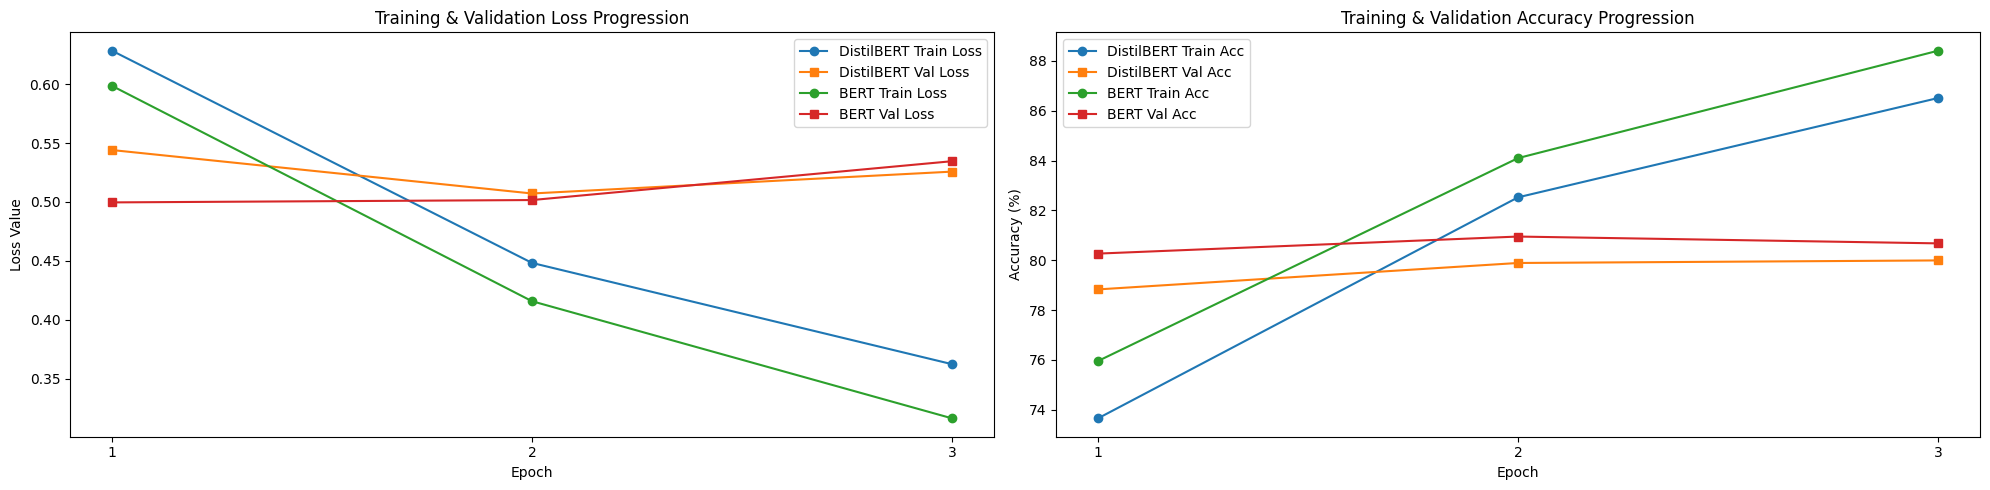

In [9]:
# Learning Curves: training and validation loss curves over epochs

epochs_range = range(1, 4)

# Training and Loss Curves to be plotted
fig, axes = plt.subplots(1, 2, figsize=(20, 5))

# Loss Progression Curves
axes[0].plot(epochs_range, history_distilbert['train_loss'], marker='o', label='DistilBERT Train Loss')
axes[0].plot(epochs_range, history_distilbert['val_loss'], marker='s', label='DistilBERT Val Loss')
axes[0].plot(epochs_range, history_bertbase['train_loss'], marker='o', label='BERT Train Loss')
axes[0].plot(epochs_range, history_bertbase['val_loss'], marker='s', label='BERT Val Loss')

axes[0].set_title('Training & Validation Loss Progression')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss Value')
axes[0].set_xticks(epochs_range)
axes[0].legend()

# Accuracy Progression Curves
# Converting raw ratio fractions to percentages for better intuitive visualization
axes[1].plot(epochs_range, [acc * 100 for acc in history_distilbert['train_acc']], marker='o', label='DistilBERT Train Acc')
axes[1].plot(epochs_range, [acc * 100 for acc in history_distilbert['val_acc']], marker='s', label='DistilBERT Val Acc')
axes[1].plot(epochs_range, [acc * 100 for acc in history_bertbase['train_acc']], marker='o', label='BERT Train Acc')
axes[1].plot(epochs_range, [acc * 100 for acc in history_bertbase['val_acc']], marker='s', label='BERT Val Acc')

axes[1].set_title('Training & Validation Accuracy Progression')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_xticks(epochs_range)
axes[1].legend()

plt.tight_layout()
plt.show()

## Insights on Learning Curves of DistilBERT and BERT over epochs

## Loss Progression Analysis

- Both DistilBERT and BERT training loss curves decrease steadily from epoch 1 to 3, confirming that both models learned the patterns of the dataset effectively.
- For both models the validation loss reaches its lowest point at epoch 2 (DistilBERT: 0.5072, BERT: 0.5016) and then turns upward in epoch 3. This divergence between the falling training loss and rising validation loss is a clear sign of overfitting beginning.
- BERT shows a more pronounced validation loss increase in epoch 3 (0.5016 → 0.5346) compared to DistilBERT (0.5072 → 0.5258), confirming that the larger model overfits faster.

## Accuracy Progression Analysis

- Both models start at very high accuracy from the first epoch (DistilBERT: 78.83%, BERT: 80.27%), which confirms the power of pretrained Transformer models on downstream tasks.
- BERT achieves a slightly better final validation accuracy (80.68%) compared to DistilBERT (79.99%), despite showing more aggressive overfitting in the training loss curve.
- Both validation accuracy curves remain relatively flat across all 3 epochs, suggesting that the models converge quickly due to their pretrained knowledge.

Extracting predictions from DistilBERT...
Extracting predictions from BERT-Base...

 DistilBERT Classification Report
              precision    recall  f1-score   support

    negative       0.86      0.89      0.88      1834
     neutral       0.65      0.57      0.61       618
    positive       0.73      0.74      0.73       472

    accuracy                           0.80      2924
   macro avg       0.75      0.73      0.74      2924
weighted avg       0.80      0.80      0.80      2924


 BERT-Base Classification Report
              precision    recall  f1-score   support

    negative       0.88      0.89      0.88      1834
     neutral       0.64      0.59      0.61       618
    positive       0.74      0.78      0.76       472

    accuracy                           0.81      2924
   macro avg       0.75      0.75      0.75      2924
weighted avg       0.80      0.81      0.81      2924



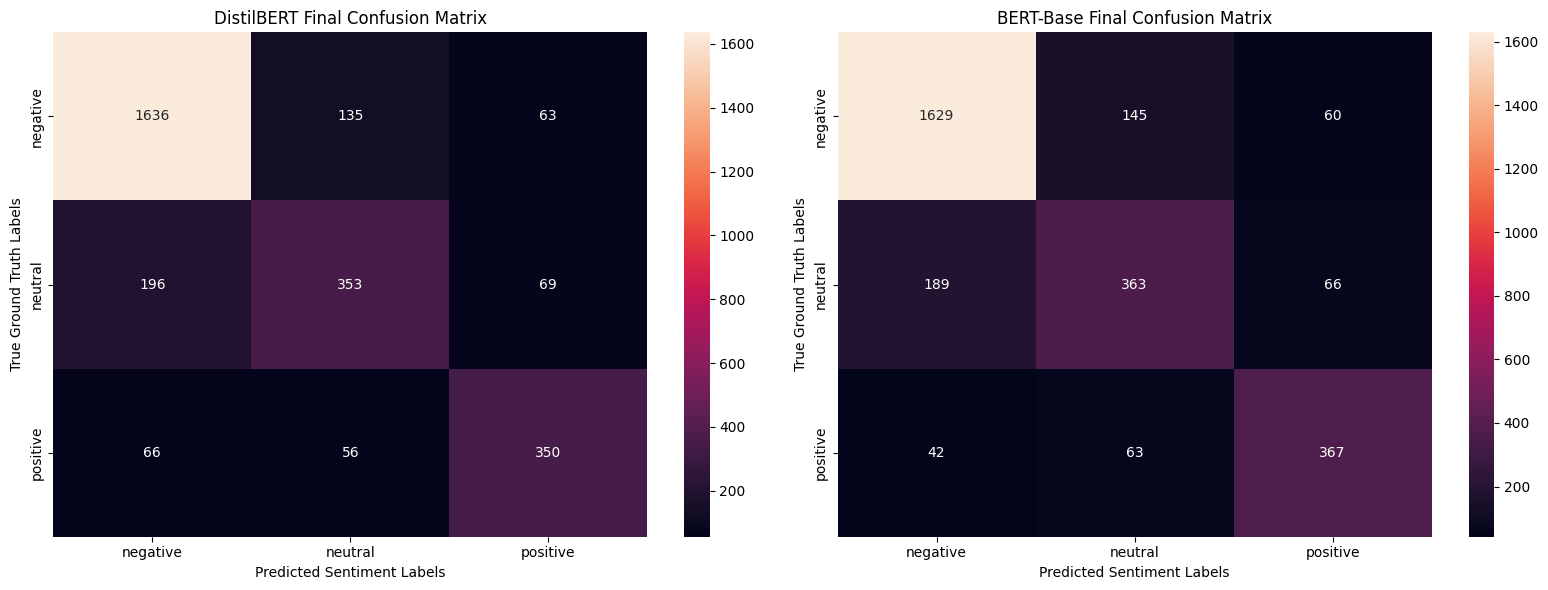

In [10]:
# Test Predictions and Confusion Matrices

def get_predictions(model, data_loader):
    """
    Helper function to run inference on the test dataset and extract
    true labels and predicted classes.
    Args:
        model (PreTrainedModel): The trained Hugging Face Transformer model used for inference.
        data_loader (DataLoader): PyTorch DataLoader containing the dataset batches to evaluate.
    Returns:
        tuple: A tuple containing two NumPy arrays: (predictions, real_values).
    """
    model.eval()
    predictions = []
    real_values = []

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            # Forward pass to extract model logits
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            _, preds = torch.max(outputs.logits, dim=1)

            # Collect results back to CPU
            predictions.extend(preds.cpu().numpy())
            real_values.extend(labels.cpu().numpy())

    return np.array(predictions), np.array(real_values)


# Extract Test Predictions for both Trained Models
print("Extracting predictions from DistilBERT...")
preds_distil, y_test_distil = get_predictions(model_distilbert, test_loader_distil)

print("Extracting predictions from BERT-Base...")
preds_bert, y_test_bert = get_predictions(model_bertbase, test_loader_bert)


# Classification Reports

# Define label categories for the axe mapping
class_names = ['negative', 'neutral', 'positive']

print("\n DistilBERT Classification Report")
print(classification_report(y_test_distil, preds_distil, target_names=class_names, zero_division=0))

print("\n BERT-Base Classification Report")
print(classification_report(y_test_bert, preds_bert, target_names=class_names, zero_division=0))

# Compute Confusion Matrices
cm_distil = confusion_matrix(y_test_distil, preds_distil)
cm_bert = confusion_matrix(y_test_bert, preds_bert)

# Plotting the Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# DistilBERT Confusion Matrix
sns.heatmap(cm_distil, annot=True, fmt='d', ax=axes[0], xticklabels=class_names, yticklabels=class_names)
axes[0].set_title('DistilBERT Final Confusion Matrix')
axes[0].set_xlabel('Predicted Sentiment Labels')
axes[0].set_ylabel('True Ground Truth Labels')

# BERT-Base Confusion Matrix
sns.heatmap(cm_bert, annot=True, fmt='d', ax=axes[1], xticklabels=class_names, yticklabels=class_names)
axes[1].set_title('BERT-Base Final Confusion Matrix')
axes[1].set_xlabel('Predicted Sentiment Labels')
axes[1].set_ylabel('True Ground Truth Labels')

plt.tight_layout()
plt.show()

## Insights on Test Predictions and Confusion Matrices

- DistilBERT achieved 80% accuracy on the test set, while BERT achieved 81%, confirming that both pretrained Transformer models are highly effective for sentiment classification.
- Both models performed almost identically across all classes, which highlights DistilBERT's efficiency — it achieves comparable results with 40% fewer parameters and significantly faster training time.
- Both models performed very well on negative tweets (F1-score: 0.88 for both), correctly identifying 1,636 and 1,629 negative tweets respectively. This was expected given that the dataset is heavily imbalanced toward negative sentiment.
- The neutral class shows the lowest performance (F1-score: 0.61 for both models), with many neutral tweets misclassified as negative. This confirms that neutral sentiment is inherently harder to distinguish in imbalanced datasets.
- BERT showed a slight edge on positive tweets (F1-score: 0.76 vs 0.73 for DistilBERT), correctly identifying 367 vs 350 positive tweets.

## Brief Explanation

## Description of the transformer model architecture
In this exercise we experimented and compared two Pretrained Transformer Models; BERT and DistilBERT.

- BERT (Bidirectional Encoder Representations from Transformers)  is a foundational natural language processing (NLP) model released by Google. It uses two pretraining tasks: Masked Language Modeling (MLM), which masks 15% of input words and asks the model to predict them, and Next Sentence Prediction (NSP), which trains the model to understand relationships between sentences. It features 12 layers (transformer blocks) and approximately 110 million parameters.

- DistilBERT is a smaller, faster and lighter version of BERT. Developed by Hugging Face, it retains 97% of BERT's language understanding capabilities while using 40% fewer parameters and running 60% faster. It cuts BERT's encoder layers in half (from 12 to 6) and removes token-type embeddings and the pooler. It uses a triple loss function combining language modeling, distillation, and cosine-distance losses


## Optimization Hyperparameters

- We used a custom linear classification layer on both pretrained models with 3 output nodes to predict three different sentiment classes (negative, neutral, positive)
- We used a very small learning rate (lr=2e-5) to perform fine-tuning. This way the models are allowed to keep their pre-existing knowledge intact, while making precise steps to learn our specific dataset.
- We chose Batch Size (32) and Sequence Length (64) based on hardware limits and dataset characteristics. Tweets tend to be shorter than a full text or an article, so a sequence length of 64 covers the majority of our tweets without wasting GPU memory. In addition, a Batch Size of 32 is the industry standard for safe Transformer training on Google Colab.
- We used only 3 Epochs because these models are pretrained and they reach overfitting too fast. The standard number is usually 3-5 epochs in these kind of models.
